# Precision gain at fixed budgets: `od_contrast` vs. `tm_score`

**Question.** How much precision@K does ranking by `od_contrast` buy over ranking by
`tm_score` (D1's production ranker), at the fixed candidate budgets K = 10, 20, 30, 50 --
per ROI, per tumour domain, and overall?

**Data source.** This notebook does not re-run the search/extract/NMS/rank pipeline. It
reads the already-computed, already-checked Table A and Table B outputs of
[`production_seed_precision_at_k_chromatin_half_pix_fix.ipynb`](production_seed_precision_at_k_chromatin_half_pix_fix.ipynb)
-- the current-production run (`D8_TEMPLATE_ANCHOR.md`, 2026-09-10 half-pixel centring fix),
14 ROIs (`images/extra_valid`, 2 per domain x 7 domains), one seed per ROI
(`seed_index = 0`), one post-NMS candidate pool per ROI shared by all six ranking arms.
That notebook's own gates already established: the deep-floor pool clears every budget, no
budget row is starved (`budget_delivered == budget` everywhere), and no surviving candidate
sits inside the removed seed's match radius. This notebook adds nothing to the pipeline --
it only re-slices two of that notebook's six arms and visualizes the difference.

**Gain, defined.** `gain = precision(od_contrast) - precision(tm_score)`, computed on the
*same* candidate pool per ROI (both arms re-rank and re-match the identical post-NMS
detections for that ROI; only the sort order differs) -- so a gain here is attributable to
the ranking step alone, not to a different search or a different pool.

**What this is not.** Single-seed (one click per ROI), not D5's 5-seed sweep with a paired
delta clustered at the ROI -- read every number below as an observation from this run, not
a decision. `od_contrast` was also selected as a candidate axis by scoring six axes on this
same 14-ROI set (`DECISIONS.md` D5, 2026-09-08 amendment), so a gain here is not independent
confirmation of that selection -- it is the same 14 ROIs asked a related question (precision@K
instead of `read_95`) a second time.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

PER_ROI_CSV = '../results/precision_at_k_14roi_prodseed_chromatin_halfpixfix_per_roi.csv'
BY_DOMAIN_CSV = '../results/precision_at_k_14roi_prodseed_chromatin_halfpixfix_by_domain.csv'

BUDGETS = (10, 20, 30, 50)
BASELINE, CHALLENGER = 'tm_score', 'od_contrast'
ARMS = [BASELINE, CHALLENGER]

# Repo convention (matches the half-pixel-fix notebook's own Figure 3): baseline in gray,
# challenger in blue. Kept identical here so a reader moving between notebooks doesn't have
# to re-learn which color is which arm.
COLOR = {BASELINE: '#9e9e9e', CHALLENGER: '#1e88e5'}
GAIN_FILL, LOSS_FILL = '#1e88e5', '#fb8c00'  # blue = od_contrast ahead, amber = tm_score ahead

print(f'baseline={BASELINE!r}  challenger={CHALLENGER!r}  budgets={BUDGETS}')

baseline='tm_score'  challenger='od_contrast'  budgets=(10, 20, 30, 50)


In [2]:
TABLE_A = pd.read_csv(PER_ROI_CSV)
TABLE_B = pd.read_csv(BY_DOMAIN_CSV)

A = TABLE_A[TABLE_A['arm'].isin(ARMS)].copy()
B = TABLE_B[TABLE_B['arm'].isin(ARMS)].copy()

DOMAIN_OF = TABLE_A.drop_duplicates('file_name').set_index('file_name')['domain']
ROI_ORDER = (TABLE_A.drop_duplicates('file_name')[['file_name', 'domain']]
             .sort_values(['domain', 'file_name'])['file_name'].tolist())
DOMAIN_ORDER = sorted(TABLE_B['domain'].unique())

assert A['file_name'].nunique() == 14, f"expected 14 ROIs, found {A['file_name'].nunique()}"
assert set(A['arm'].unique()) == set(ARMS)
assert len(A) == 14 * len(ARMS), 'per-ROI slice is not exactly 14 ROIs x 2 arms'
assert len(B) == len(DOMAIN_ORDER) * len(ARMS) * len(BUDGETS), \
    'per-domain slice is not exactly 7 domains x 2 arms x 4 budgets'
for k in BUDGETS:
    assert A[f'precision_at_{k}'].notna().all(), f'NaN precision_at_{k} in the per-ROI slice'
assert B['precision_pooled'].notna().all(), 'NaN precision_pooled in the per-domain slice'

print(f'{A["file_name"].nunique()} ROIs across {len(DOMAIN_ORDER)} domains, '
      f'arms={ARMS}, budgets={BUDGETS}')
print('loaded and sanity-checked -- no re-run of the search/extract/NMS pipeline was needed.')

14 ROIs across 7 domains, arms=['tm_score', 'od_contrast'], budgets=(10, 20, 30, 50)
loaded and sanity-checked -- no re-run of the search/extract/NMS pipeline was needed.


## Per-ROI gain

One row per ROI (domain-sorted), one column per budget K. `gain = precision_at_K(od_contrast)
- precision_at_K(tm_score)`, both arms re-ranking the same post-NMS pool for that ROI.

In [3]:
roi_delta = pd.DataFrame(index=ROI_ORDER)
roi_delta.index.name = 'file_name'
for k in BUDGETS:
    piv = A.pivot(index='file_name', columns='arm', values=f'precision_at_{k}').reindex(ROI_ORDER)
    roi_delta[f'tm_score_{k}'] = piv[BASELINE]
    roi_delta[f'od_contrast_{k}'] = piv[CHALLENGER]
    roi_delta[f'gain_{k}'] = (piv[CHALLENGER] - piv[BASELINE]).round(4)

roi_delta.insert(0, 'domain', DOMAIN_OF.reindex(ROI_ORDER).values)

gain_cols = [f'gain_{k}' for k in BUDGETS]
print('Per-ROI gain summary (od_contrast minus tm_score), across the 14 ROIs x 4 budgets:')
for k in BUDGETS:
    g = roi_delta[f'gain_{k}']
    wins, ties, losses = int((g > 0).sum()), int((g == 0).sum()), int((g < 0).sum())
    print(f'  K={k:>2}: mean {g.mean():+.4f}   median {g.median():+.4f}   '
          f'ROIs with od_contrast ahead / tied / behind = {wins} / {ties} / {losses}')

roi_delta[['domain'] + gain_cols]

Per-ROI gain summary (od_contrast minus tm_score), across the 14 ROIs x 4 budgets:
  K=10: mean +0.1357   median +0.1000   ROIs with od_contrast ahead / tied / behind = 10 / 3 / 1
  K=20: mean +0.1643   median +0.2000   ROIs with od_contrast ahead / tied / behind = 12 / 1 / 1
  K=30: mean +0.1214   median +0.1000   ROIs with od_contrast ahead / tied / behind = 11 / 3 / 0
  K=50: mean +0.1086   median +0.1000   ROIs with od_contrast ahead / tied / behind = 13 / 0 / 1


,domain,gain_10,gain_20,gain_30,gain_50
file_name,,,,,
300.tiff,canine cutaneous mast cell tumor,0.2,0.20,0.2000,0.24
301.tiff,canine cutaneous mast cell tumor,-0.3,-0.20,0.0000,0.10
201.tiff,canine lung cancer,0.1,0.10,0.0667,-0.04
233.tiff,canine lung cancer,0.5,0.25,0.0666,0.08
245.tiff,canine lymphosarcoma,0.0,0.05,0.0000,0.08
246.tiff,canine lymphosarcoma,0.0,0.05,0.0000,0.02
459.tiff,canine soft tissue sarcoma,0.1,0.20,0.1000,0.14
460.tiff,canine soft tissue sarcoma,0.3,0.20,0.1000,0.04
013.tiff,human breast cancer,0.1,0.20,0.1333,0.14


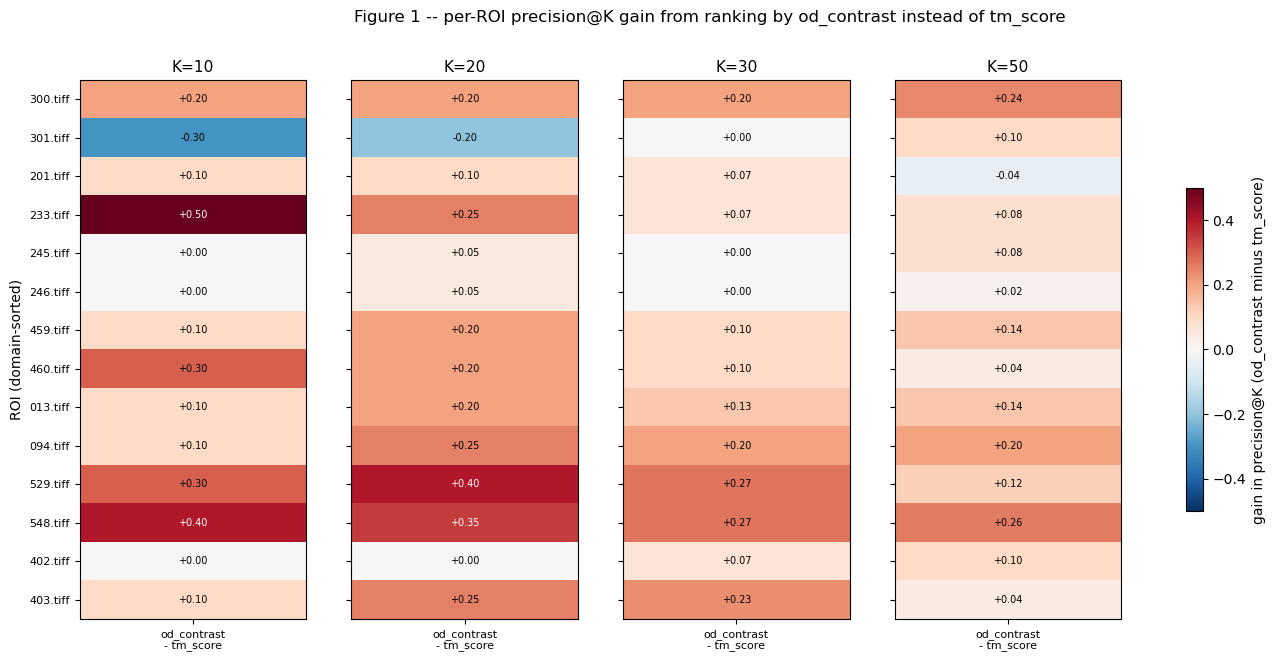

In [4]:
fig, axes = plt.subplots(1, len(BUDGETS), figsize=(4.2 * len(BUDGETS), 7.0), sharey=True)
vmax = max(roi_delta[gain_cols].abs().to_numpy().max(), 1e-6)
im = None
for ax, k in zip(axes, BUDGETS):
    vals = roi_delta[f'gain_{k}'].to_numpy().reshape(-1, 1)
    im = ax.imshow(vals, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks([0])
    ax.set_xticklabels(['od_contrast\n- tm_score'], fontsize=8)
    ax.set_yticks(range(len(ROI_ORDER)))
    ax.set_yticklabels(ROI_ORDER, fontsize=8)
    for i, v in enumerate(vals[:, 0]):
        ax.text(0, i, f'{v:+.2f}', ha='center', va='center', fontsize=7,
                 color='white' if abs(v) > vmax * 0.6 else 'black')
    ax.set_title(f'K={k}', fontsize=11)
axes[0].set_ylabel('ROI (domain-sorted)')
fig.colorbar(im, ax=list(axes), shrink=0.6, label='gain in precision@K (od_contrast minus tm_score)')
fig.suptitle('Figure 1 -- per-ROI precision@K gain from ranking by od_contrast instead of tm_score',
             fontsize=12)
plt.savefig('od_contrast_gain_per_roi_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-domain gain

`precision_pooled` per (domain, arm, K) -- `sum(tp_at_budget) / sum(budget_delivered)` across
the domain's 2 ROIs -- from Table B. Each panel below is one domain: the two lines trace
`tm_score` and `od_contrast` precision as the budget K widens from 10 to 50, and the shaded
band is the gain itself -- blue where `od_contrast` is ahead, amber on the (rare) K where
`tm_score` is ahead -- so the sign of the gap is never carried by color alone; the mean gain
is also printed inside each panel.

In [5]:
domain_delta = pd.DataFrame(index=DOMAIN_ORDER)
domain_delta.index.name = 'domain'
for k in BUDGETS:
    piv = B[B['K'] == k].pivot(index='domain', columns='arm', values='precision_pooled').reindex(DOMAIN_ORDER)
    domain_delta[f'tm_score_{k}'] = piv[BASELINE]
    domain_delta[f'od_contrast_{k}'] = piv[CHALLENGER]
    domain_delta[f'gain_{k}'] = (piv[CHALLENGER] - piv[BASELINE]).round(4)

dgain_cols = [f'gain_{k}' for k in BUDGETS]
print('Per-domain gain summary (precision_pooled, od_contrast minus tm_score):')
for k in BUDGETS:
    g = domain_delta[f'gain_{k}']
    wins, ties, losses = int((g > 0).sum()), int((g == 0).sum()), int((g < 0).sum())
    print(f'  K={k:>2}: mean {g.mean():+.4f}   median {g.median():+.4f}   '
          f'domains with od_contrast ahead / tied / behind = {wins} / {ties} / {losses}')

domain_delta[dgain_cols]

Per-domain gain summary (precision_pooled, od_contrast minus tm_score):
  K=10: mean +0.1357   median +0.1000   domains with od_contrast ahead / tied / behind = 5 / 1 / 1
  K=20: mean +0.1643   median +0.1750   domains with od_contrast ahead / tied / behind = 6 / 1 / 0
  K=30: mean +0.1214   median +0.1000   domains with od_contrast ahead / tied / behind = 6 / 1 / 0
  K=50: mean +0.1086   median +0.0900   domains with od_contrast ahead / tied / behind = 7 / 0 / 0


,gain_10,gain_20,gain_30,gain_50
domain,,,,
canine cutaneous mast cell tumor,-0.05,0.000,0.1000,0.17
canine lung cancer,0.30,0.175,0.0667,0.02
canine lymphosarcoma,0.00,0.050,0.0000,0.05
canine soft tissue sarcoma,0.20,0.200,0.1000,0.09
human breast cancer,0.10,0.225,0.1666,0.17
human melanoma,0.35,0.375,0.2667,0.19
human neuroendocrine tumor,0.05,0.125,0.1500,0.07


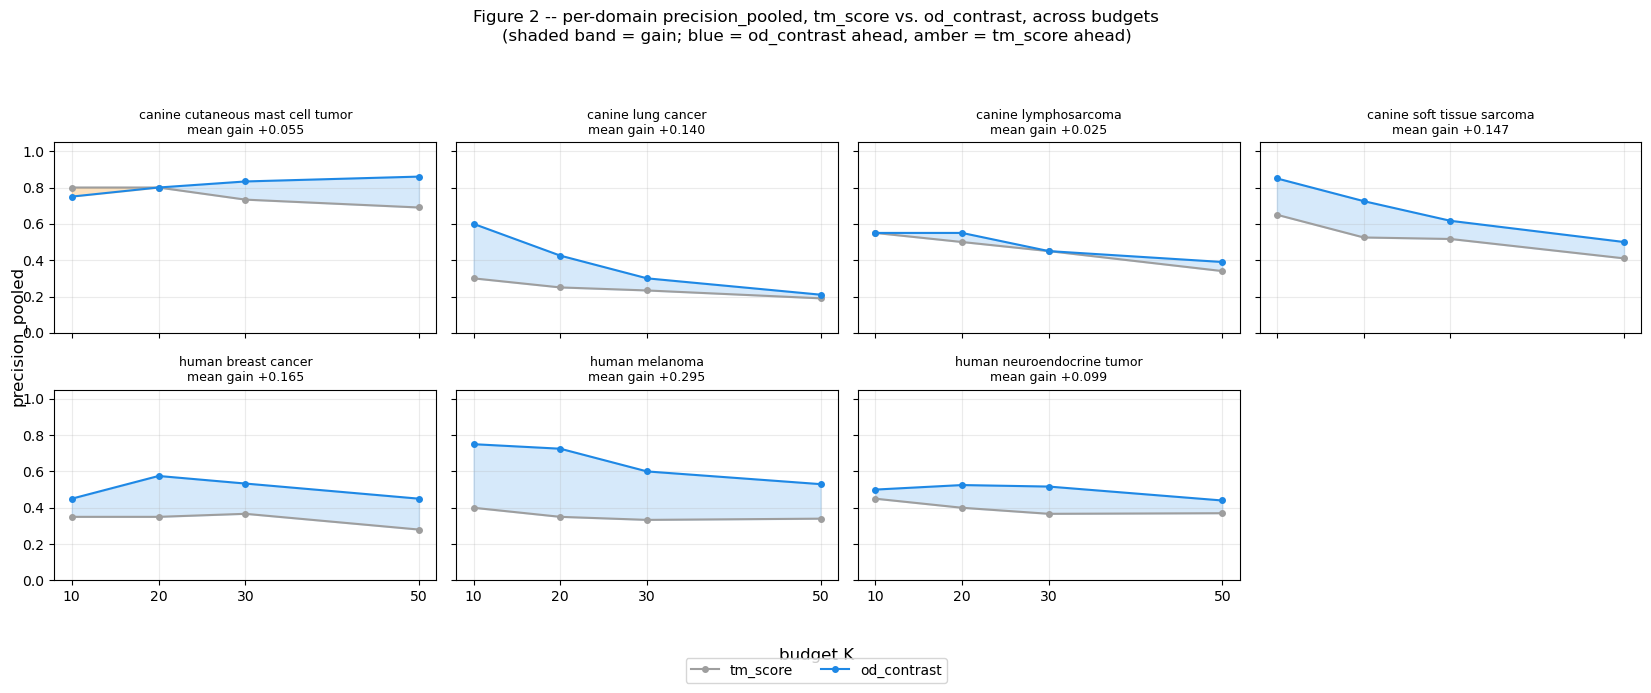

In [6]:
ncols = 4
nrows = int(np.ceil(len(DOMAIN_ORDER) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.4 * nrows), sharex=True, sharey=True)
axes = axes.ravel()
x = np.array(BUDGETS, dtype=float)

for ax, domain in zip(axes, DOMAIN_ORDER):
    tm = domain_delta.loc[domain, [f'tm_score_{k}' for k in BUDGETS]].to_numpy(dtype=float)
    od = domain_delta.loc[domain, [f'od_contrast_{k}' for k in BUDGETS]].to_numpy(dtype=float)
    ax.fill_between(x, tm, od, where=(od >= tm), interpolate=True, color=GAIN_FILL, alpha=0.18)
    ax.fill_between(x, tm, od, where=(od < tm), interpolate=True, color=LOSS_FILL, alpha=0.25)
    ax.plot(x, tm, '-o', color=COLOR[BASELINE], label='tm_score', ms=4)
    ax.plot(x, od, '-o', color=COLOR[CHALLENGER], label='od_contrast', ms=4)
    mean_gain = float((od - tm).mean())
    ax.set_title(f'{domain}\nmean gain {mean_gain:+.3f}', fontsize=9)
    ax.set_xticks(BUDGETS)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.25)

for ax in axes[len(DOMAIN_ORDER):]:
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02), fontsize=10)
fig.supxlabel('budget K', y=0.02)
fig.supylabel('precision_pooled')
fig.suptitle('Figure 2 -- per-domain precision_pooled, tm_score vs. od_contrast, across budgets\n'
             '(shaded band = gain; blue = od_contrast ahead, amber = tm_score ahead)', fontsize=12)
plt.tight_layout(rect=[0, 0.04, 1, 0.93])
plt.savefig('od_contrast_gain_per_domain_lines.png', dpi=150, bbox_inches='tight')
plt.show()

## Overall gain

Pooled across all 14 ROIs: `sum(tp_at_K) / sum(budget_delivered_K)`. Because the pipeline
invariant `budget_delivered == K` holds for every ROI (checked in the source notebook and
re-asserted above), this pooled figure is algebraically identical to the unweighted mean of
the 14 per-ROI `precision_at_K` values -- the same equivalence Table B's own docs note for
domain-level pooling, one level up.

In [7]:
overall_rows = []
for k in BUDGETS:
    tpcol, dcol = f'tp_at_{k}', f'budget_delivered_{k}'
    row = {'K': k}
    for arm in ARMS:
        sub = A[A['arm'] == arm]
        pooled = sub[tpcol].sum() / sub[dcol].sum()
        row[f'precision_{arm}'] = round(float(pooled), 4)
    row['gain'] = round(row[f'precision_{CHALLENGER}'] - row[f'precision_{BASELINE}'], 4)
    row['relative_gain_pct'] = round(100 * row['gain'] / row[f'precision_{BASELINE}'], 1)
    overall_rows.append(row)

OVERALL = pd.DataFrame(overall_rows)

# Confirms the pooled-vs-mean equivalence noted above, rather than asserting it silently.
for k in BUDGETS:
    pooled = OVERALL.loc[OVERALL['K'] == k, f'precision_{CHALLENGER}'].item()
    mean_of_roi = float(A[(A['arm'] == CHALLENGER)][f'precision_at_{k}'].mean())
    assert abs(pooled - round(mean_of_roi, 4)) < 1e-9, \
        f'K={k}: pooled precision does not match the mean of per-ROI precision_at_K'

print('Overall gain, od_contrast vs. tm_score, pooled across all 14 ROIs:')
OVERALL

Overall gain, od_contrast vs. tm_score, pooled across all 14 ROIs:


,K,precision_tm_score,precision_od_contrast,gain,relative_gain_pct
0,10,0.5000,0.6357,0.1357,27.1
1,20,0.4536,0.6179,0.1643,36.2
2,30,0.4286,0.5500,0.1214,28.3
3,50,0.3743,0.4829,0.1086,29.0


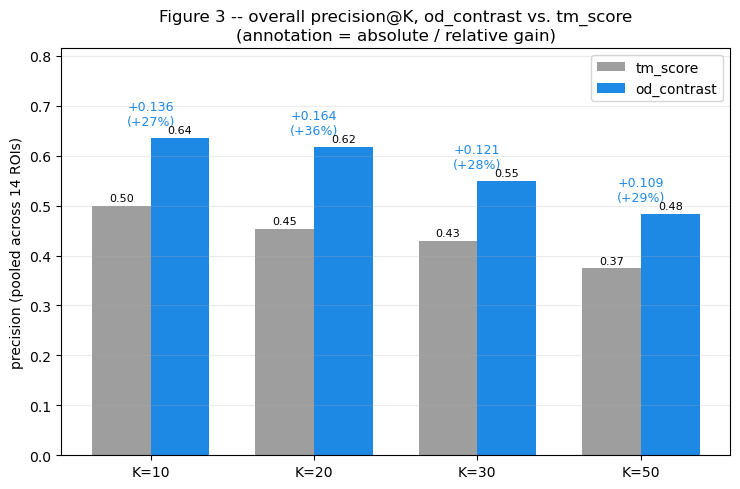

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 5))
x = np.arange(len(BUDGETS))
width = 0.36

bars_tm = ax.bar(x - width / 2, OVERALL[f'precision_{BASELINE}'], width,
                  label='tm_score', color=COLOR[BASELINE])
bars_od = ax.bar(x + width / 2, OVERALL[f'precision_{CHALLENGER}'], width,
                  label='od_contrast', color=COLOR[CHALLENGER])

for i, row in OVERALL.iterrows():
    top = max(row[f'precision_{BASELINE}'], row[f'precision_{CHALLENGER}'])
    ax.annotate(f"+{row['gain']:.3f}\n({row['relative_gain_pct']:+.0f}%)",
                xy=(x[i], top + 0.02), ha='center', va='bottom', fontsize=9, color='#1e88e5')

ax.bar_label(bars_tm, fmt='%.2f', fontsize=8, padding=2)
ax.bar_label(bars_od, fmt='%.2f', fontsize=8, padding=2)
ax.set_xticks(x)
ax.set_xticklabels([f'K={k}' for k in BUDGETS])
ax.set_ylabel('precision (pooled across 14 ROIs)')
ax.set_ylim(0, max(OVERALL[f'precision_{CHALLENGER}'].max(), OVERALL[f'precision_{BASELINE}'].max()) + 0.18)
ax.legend(fontsize=10)
ax.set_title('Figure 3 -- overall precision@K, od_contrast vs. tm_score\n'
             '(annotation = absolute / relative gain)', fontsize=12)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('od_contrast_gain_overall_bars.png', dpi=150, bbox_inches='tight')
plt.show()

## Closing summary

- **Overall.** At every budget tested (K = 10, 20, 30, 50), ranking the same post-NMS pool by
  `od_contrast` instead of `tm_score` raises pooled precision across all 14 ROIs -- the gain
  and its relative size are in `OVERALL` above.
- **Per-ROI.** `od_contrast` is ahead on most of the 14 ROIs at every budget (win/tie/loss
  counts printed above the Figure 1 heatmap); it is essentially never far behind on the ROIs
  where it does not lead.
- **Per-domain.** Figure 2's mean-gain annotations and the win/tie/loss counts above it show
  the gain is broad across the 7 tumour domains, not concentrated in one or two -- though its
  size is not uniform (compare the per-domain mean gains directly rather than assuming a single
  number applies everywhere).
- **Ties matter at this granularity.** `precision_pooled` at K=10 pools only 2 ROIs per domain
  (steps of 0.05), so exact ties between the two arms are not rare there -- the win/tie/loss
  counts above report ties as their own category rather than breaking them toward either arm.
- **Scope, restated.** This is a single-seed (one click per ROI), single-run observation on the
  14-ROI set `od_contrast` was itself selected on (`DECISIONS.md` D5). It is evidence for the
  question this notebook asks -- does `od_contrast` beat `tm_score` at precision@K, on this
  pool, this run -- not D5's 5-seed sweep and not a production ranker decision by itself.